In [1]:
!curl -L "https://universe.roboflow.com/ds/glquRaJDf9?key=1kWinBXVTQ" > roboflow.zip; unzip roboflow.zip; rm roboflow.zip

Streaming output truncated to the last 5000 lines.
  inflating: train/labels/001677_JPG_jpg.rf.414e120831f7e7f30447cb3cb26bdc83.txt  
 extracting: train/labels/001677_JPG_jpg.rf.d0e22a225cbb317066ae2e6efd3dbcc2.txt  
  inflating: train/labels/001678_JPG_jpg.rf.21782caf845bde6574cb51b3f5c74490.txt  
  inflating: train/labels/001678_JPG_jpg.rf.4de99d4836e879bc0a6b13d15eefe346.txt  
  inflating: train/labels/001678_JPG_jpg.rf.d9b987c7dd66459a58b74d90a6970de7.txt  
  inflating: train/labels/001679_JPG_jpg.rf.7f8083798d74d6e40543f776ec116c6a.txt  
  inflating: train/labels/001679_JPG_jpg.rf.c11f3850b8f5630a0b21810e0a256c90.txt  
  inflating: train/labels/001679_JPG_jpg.rf.f0cdb80eb57c2cf67c5306cbf7c19aac.txt  
  inflating: train/labels/001680_JPG_jpg.rf.05690ffb9e45dcb471a95f0b96806331.txt  
  inflating: train/labels/001680_JPG_jpg.rf.8472e670be11dc0438f4a3e001e124bb.txt  
  inflating: train/labels/001680_JPG_jpg.rf.fc6132ab57b715e2192ea08bbc90067d.txt  
  inflating: train/labels/001681_JPG

In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.8/978.8 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 68.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 103.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

In [3]:
import os
import torch
import numpy as np
from sklearn.cluster import KMeans
from torchvision import models, transforms
from PIL import Image
from util import preprocess_image, compare_original_and_adversarial_png
import torch
from ultralytics import YOLO

import sys
import io
class SuppressPrints:  # Context manager to silence function output
    def __enter__(self):
        self._original_stdout = sys.stdout
        sys.stdout = io.StringIO()
    def __exit__(self, exc_type, exc_val, exc_tb):
        sys.stdout = self._original_stdout


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
model_path = "/content/drive/MyDrive/yolo/yolov8n_TrafficSigns.pt"
model = YOLO(model_path)

In [6]:
!cp /content/drive/MyDrive/yolo/adversarial_data_set_pgd_1.zip /content/
!unzip adversarial_data_set_pgd_1.zip -d /content/
!mv /content/content/adversarial_dataset/ /content/adversarial_dataset

Archive:  adversarial_data_set_pgd_1.zip
   creating: /content/content/adversarial_dataset/
  inflating: /content/content/adversarial_dataset/labels.cache  
   creating: /content/content/adversarial_dataset/labels/
  inflating: /content/content/adversarial_dataset/labels/00004_00060_00021_png.rf.a81a5ba2fb654d944063ddd496a46662.txt  
  inflating: /content/content/adversarial_dataset/labels/road446_png.rf.c209c8b5929313d1258667af1a6a37ae.txt  
  inflating: /content/content/adversarial_dataset/labels/00001_00028_00017_png.rf.98d01270a314b8cc77f6ad92f979b47f.txt  
  inflating: /content/content/adversarial_dataset/labels/001261_jpg.rf.7aab90697a4784411cbc2785e626e004.txt  
  inflating: /content/content/adversarial_dataset/labels/road59_png.rf.40b97d5dddbee9679979779c88bb7348.txt  
  inflating: /content/content/adversarial_dataset/labels/000811_jpg.rf.f5bb7753902ae5b5fd8f5e7f601da271.txt  
  inflating: /content/content/adversarial_dataset/labels/road692_png.rf.ab199ab022b948479bfba7b3c8fd66

In [7]:
import os
import glob
import random
import io
import shutil

import numpy as np
from PIL import Image

def jpeg_compression(image, quality=10):
    """Apply JPEG compression to an image."""
    buf = io.BytesIO()
    image.save(buf, format="JPEG", quality=quality)
    buf.seek(0)
    return Image.open(buf).convert("RGB")

def random_resize(image, scale_range=(0.75, 1.25)):
    """Randomly resize image; returns (resized_image, scale_factor)."""
    scale = random.uniform(*scale_range)
    new_w = int(image.width * scale)
    new_h = int(image.height * scale)
    return image.resize((new_w, new_h), Image.Resampling.LANCZOS), scale

def rescale_yolo_labels(txt_lines, scale, old_w, old_h, new_w, new_h):
    """
    Given lines of YOLO labels (cls x_center_rel y_center_rel w_rel h_rel),
    recalc normalized coords after a uniform resize.
    """
    out = []
    for ln in txt_lines:
        cls, x_rel, y_rel, w_rel, h_rel = ln.strip().split()
        x_rel = float(x_rel); y_rel = float(y_rel)
        w_rel = float(w_rel); h_rel = float(h_rel)

        # absolute old
        x_abs = x_rel * old_w
        y_abs = y_rel * old_h
        w_abs = w_rel * old_w
        h_abs = h_rel * old_h

        # absolute new
        x_abs_new = x_abs * scale
        y_abs_new = y_abs * scale
        w_abs_new = w_abs * scale
        h_abs_new = h_abs * scale

        # back to normalized new
        x_rel_new = x_abs_new / new_w
        y_rel_new = y_abs_new / new_h
        w_rel_new = w_abs_new / new_w
        h_rel_new = h_abs_new / new_h

        out.append(f"{cls} {x_rel_new:.6f} {y_rel_new:.6f} {w_rel_new:.6f} {h_rel_new:.6f}\n")
    return out

if __name__ == "__main__":
    img_in  = "/content/adversarial_dataset/images"
    lbl_in  = "/content/adversarial_dataset/labels"
    img_out = "/content/compressed_dataset/images"
    lbl_out = "/content/compressed_dataset/labels"

    os.makedirs(img_out, exist_ok=True)
    os.makedirs(lbl_out, exist_ok=True)

    for i, img_path in enumerate(glob.glob(os.path.join(img_in, "*.png"))):
        base = os.path.splitext(os.path.basename(img_path))[0]
        lbl_path = os.path.join(lbl_in,  base + ".txt")
        out_img  = os.path.join(img_out, base + ".png")
        out_lbl  = os.path.join(lbl_out, base + ".txt")

        # load and compress
        img = Image.open(img_path).convert("RGB")
        comp = jpeg_compression(img, quality=10)

        # resize (and get scale)
        resized, scale = random_resize(comp, scale_range=(0.75, 1.25))
        w_new, h_new = resized.width, resized.height
        w_old, h_old = img.width, img.height

        # save image
        resized.save(out_img)

        # handle label
        if os.path.exists(lbl_path):
            # if you only do uniform scaling, the normalized coords stay the same,
            # so you could simply: shutil.copy(lbl_path, out_lbl)
            #
            # but here’s the full recalc in case you ever use non‑uniform transforms:
            with open(lbl_path) as f:
                lines = f.readlines()
            new_lines = rescale_yolo_labels(lines, scale, w_old, h_old, w_new, h_new)
            with open(out_lbl, "w") as f:
                f.writelines(new_lines)

        # progress
        if i % 100 == 0:
            print(f"Processed {i} images")

    print("Done.")


Processed 0 images
Processed 100 images
Processed 200 images
Processed 300 images
Processed 400 images
Processed 500 images
Processed 600 images
Done.


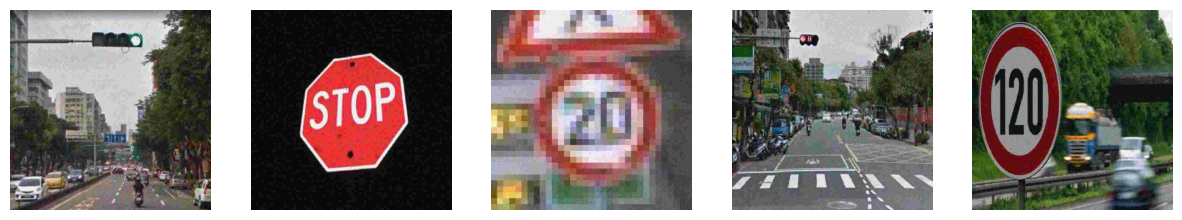

In [11]:
# prompt: display some random  images from output_dir

import matplotlib.pyplot as plt
import random
import glob

# Assuming output_dir is defined as in your previous code
output_dir = "/content/compressed_dataset/images"

# Number of random images to display
num_images = 5

# Get a list of image file paths from output_dir
image_files = glob.glob(os.path.join(output_dir, "*.png"))

# Select random image files
random_image_files = random.sample(image_files, min(num_images, len(image_files)))

# Display the images
plt.figure(figsize=(15, 5))  # Adjust figure size as needed

for i, image_file in enumerate(random_image_files):
    img = Image.open(image_file)
    plt.subplot(1, num_images, i + 1)  # Create subplots for each image
    plt.imshow(img)
    plt.axis('off')  # Hide axis ticks and labels

plt.show()


In [12]:
results = model.val(
    data="/content/adv.yaml",
    split="test",
    imgsz=640,
    batch=32,
    conf = 0.25
)

Ultralytics 8.3.111 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)


100%|██████████| 755k/755k [00:00<00:00, 21.2MB/s]

val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2483.5±1099.4 MB/s, size: 343.1 KB)



val: Scanning /content/compressed_dataset/labels... 636 images, 1 backgrounds, 1 corrupt: 100%|██████████| 636/636 [00:00<00:00, 1341.32it/s]

val: WARNING ⚠️ /content/compressed_dataset/images/001462_jpg.rf.74e5ef7f33ea5394b62966599756eb76.png: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0006]
val: New cache created: /content/compressed_dataset/labels.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 20/20 [00:13<00:00,  1.47it/s]


                   all        635        767      0.876      0.727      0.836      0.716
           Green Light         77        110      0.744      0.609      0.737      0.426
             Red Light         71         94      0.814      0.511      0.691      0.442
        Speed Limit 10          2          3          1      0.333      0.667      0.533
       Speed Limit 100         45         46      0.771      0.804      0.862      0.765
       Speed Limit 110         21         21      0.929      0.619      0.793      0.708
       Speed Limit 120         39         43      0.824      0.651      0.773      0.687
        Speed Limit 20         46         46      0.956      0.935      0.963       0.86
        Speed Limit 30         60         60      0.821      0.767      0.859      0.798
        Speed Limit 40         51         53      0.923      0.906      0.946      0.844
        Speed Limit 50         46         49      0.818      0.735      0.836      0.763
        Speed Limit 6

In [14]:
img_in  = "/content/test/images"
lbl_in  = "/content/test/labels"
img_out = "/content/data/images"
lbl_out = "/content/data/labels"

os.makedirs(img_out, exist_ok=True)
os.makedirs(lbl_out, exist_ok=True)

for i, img_path in enumerate(glob.glob(os.path.join(img_in, "*.jpg"))):
  base = os.path.splitext(os.path.basename(img_path))[0]
  lbl_path = os.path.join(lbl_in,  base + ".txt")
  out_img  = os.path.join(img_out, base + ".jpg")
  out_lbl  = os.path.join(lbl_out, base + ".txt")

  # load and compress
  img = Image.open(img_path).convert("RGB")
  comp = jpeg_compression(img, quality=10)

  # resize (and get scale)
  resized, scale = random_resize(comp, scale_range=(0.75, 1.25))
  w_new, h_new = resized.width, resized.height
  w_old, h_old = img.width, img.height

  # save image
  resized.save(out_img)

  # handle label
  if os.path.exists(lbl_path):
      # if you only do uniform scaling, the normalized coords stay the same,
      # so you could simply: shutil.copy(lbl_path, out_lbl)
      #
      # but here’s the full recalc in case you ever use non‑uniform transforms:
      with open(lbl_path) as f:
          lines = f.readlines()
      new_lines = rescale_yolo_labels(lines, scale, w_old, h_old, w_new, h_new)
      with open(out_lbl, "w") as f:
          f.writelines(new_lines)

  # progress
  if i % 100 == 0:
      print(f"Processed {i} images")

print("Done.")

Processed 0 images
Processed 100 images
Processed 200 images
Processed 300 images
Processed 400 images
Processed 500 images
Processed 600 images
Done.


In [15]:
results = model.val(
    data="/content/data.yaml",
    split="test",
    imgsz=640,
    batch=32,
    conf = 0.25
)

Ultralytics 8.3.111 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1266.3±530.6 MB/s, size: 33.4 KB)


val: Scanning /content/data/labels... 638 images, 1 backgrounds, 1 corrupt: 100%|██████████| 638/638 [00:00<00:00, 2626.16it/s]

val: WARNING ⚠️ /content/data/images/001462_jpg.rf.74e5ef7f33ea5394b62966599756eb76.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0006]
val: New cache created: /content/data/labels.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 20/20 [00:09<00:00,  2.19it/s]


                   all        637        769      0.861       0.81      0.864      0.761
           Green Light         77        110      0.849      0.718      0.816      0.544
             Red Light         71         94      0.808      0.628      0.743      0.499
        Speed Limit 10          2          3        0.5      0.333      0.333        0.3
       Speed Limit 100         45         46        0.8       0.87      0.916      0.824
       Speed Limit 110         21         21          1      0.714      0.857      0.785
       Speed Limit 120         39         43      0.911      0.953      0.962      0.868
        Speed Limit 20         46         46      0.915      0.935      0.964      0.873
        Speed Limit 30         60         60      0.926      0.833      0.908      0.846
        Speed Limit 40         51         53      0.836      0.962      0.976      0.859
        Speed Limit 50         47         50      0.889        0.8      0.882      0.825
        Speed Limit 6

In [ ]:
|!rm -rf /content/adversarial_dataset/

In [72]:
!rm -rf /content/compressed_dataset/